In [1]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
scroot = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
X = mmread(f"{scroot}/GSE161824_A549_KRAS.processed.matrix.mtx").tocsr()

In [4]:
# Load gene names and barcodes
genes = pd.read_csv(f"{scroot}/GSE161824_A549_KRAS.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{scroot}/GSE161824_A549_KRAS.processed.cells.csv", header=None)

In [5]:
import anndata as ad
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
print(adata)

AnnData object with n_obs × n_vars = 90262 × 1145


In [7]:
# Calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [9]:
print(adata)

AnnData object with n_obs × n_vars = 90262 × 1145
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [10]:
barcodes_mut = pd.read_csv('/work/users/k/r/kritis/database_analysis/KRAS_example/barcodes/RBM15_barcodes.csv')

In [11]:
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [12]:
WT_codes = pd.read_csv('/work/users/k/r/kritis/database_analysis/KRAS_example/KRAS_WT_barcodes.csv')['cell_barcode'].tolist()
wt_barcodes = set(WT_codes)
target_barcodes = set(barcode_list)

In [13]:
adata.obs['mut'] = 'Other'  # default
adata.obs.loc[adata.obs_names.isin(target_barcodes), 'mut'] = 'Target'
adata.obs.loc[adata.obs_names.isin(wt_barcodes), 'mut'] = 'WT'

In [14]:
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()
adata_wt = adata[adata.obs['mut'] == 'WT'].copy()

In [15]:
genes = pd.read_csv('/work/users/k/r/kritis/database_analysis/gene_set_cleaned/files/RBM15_geneset.csv')

In [16]:
gene_list = genes['0'].tolist()

In [17]:
gene_list = [g for g in gene_list if g in adata.var_names]
print(f"Using {len(gene_list)} genes from your list.")

Using 18 genes from your list.


In [18]:
X = adata[:, gene_list].X
if not isinstance(X, np.ndarray):
    X = X.toarray()  # in case it's sparse

avg_expr = X.mean(axis=1)
adata.obs['gene_signature_avg'] = avg_expr

In [19]:
sc.tl.score_genes(adata, gene_list, score_name='gene_set_enrichment_score')

/tmp/ipykernel_3134662/281478163.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=adata.obs, x="mut", y="gene_set_enrichment_score", inner="box", palette='pastel')


<Axes: xlabel='mut', ylabel='gene_set_enrichment_score'>

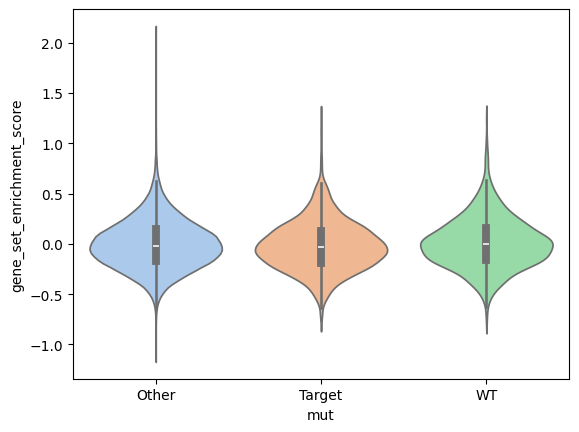

In [20]:
sns.violinplot(data=adata.obs, x="mut", y="gene_set_enrichment_score", inner="box", palette='pastel')

<Axes: xlabel='mut', ylabel='gene_set_enrichment_score'>

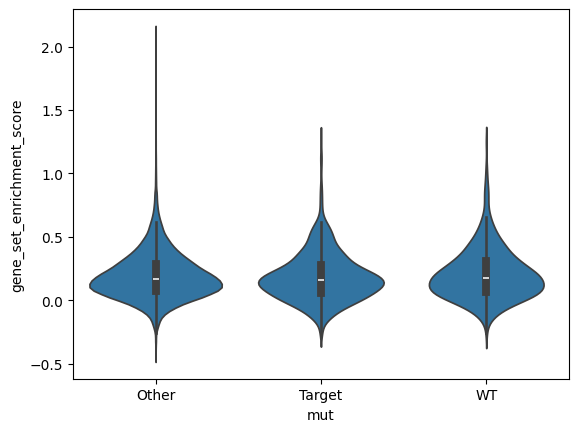

In [21]:
expressing = (adata[:, gene_list].X.toarray().sum(axis=1) > 0)
adata.obs['expressing_signature'] = np.where(expressing, 'Expressing', 'Not expressing')

# Then plot just the expressing ones
sns.violinplot(data=adata.obs[expressing], x='mut', y='gene_set_enrichment_score')

/tmp/ipykernel_3134662/386510469.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')


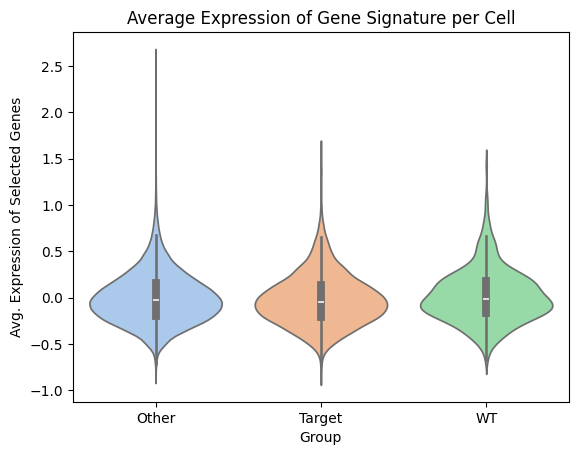

In [22]:
sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')
plt.title('Average Expression of Gene Signature per Cell')
plt.ylabel('Avg. Expression of Selected Genes')
plt.xlabel('Group')
plt.show()

<Axes: xlabel='mut', ylabel='gene_signature_avg'>

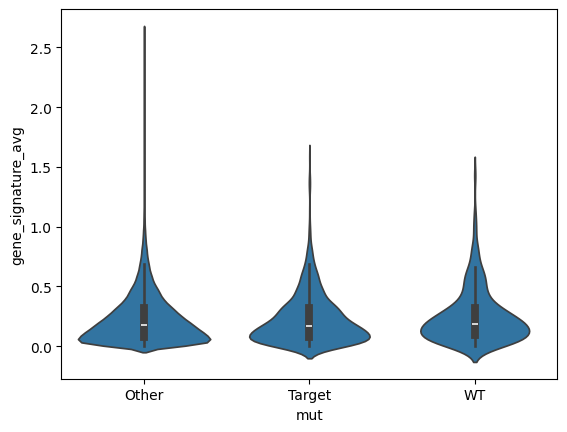

In [23]:
expressing = (adata[:, gene_list].X.toarray().sum(axis=1) > 0)
adata.obs['expressing_signature'] = np.where(expressing, 'Expressing', 'Not expressing')

# Then plot just the expressing ones
sns.violinplot(data=adata.obs[expressing], x='mut', y='gene_signature_avg')

In [24]:
# Define your group labels
is_target = adata.obs['mut'] == 'Target'
is_other = adata.obs['mut'] == 'Other'
is_wt = adata.obs['mut'] == 'WT'

# Use the per-cell gene set score (computed via sc.tl.score_genes)
gene_set_score_col = 'gene_set_enrichment_score'  # or whatever name you used

# Collect data
data = [
    {'Group': 'Target', 'Subset': 'Gene Set Score', 'Mean': adata.obs.loc[is_target, gene_set_score_col].mean()},
    {'Group': 'Other', 'Subset': 'Gene Set Score', 'Mean': adata.obs.loc[is_other, gene_set_score_col].mean()},
    {'Group': 'WT', 'Subset': 'Gene Set Score', 'Mean': adata.obs.loc[is_wt, gene_set_score_col].mean()}
]

df = pd.DataFrame(data)

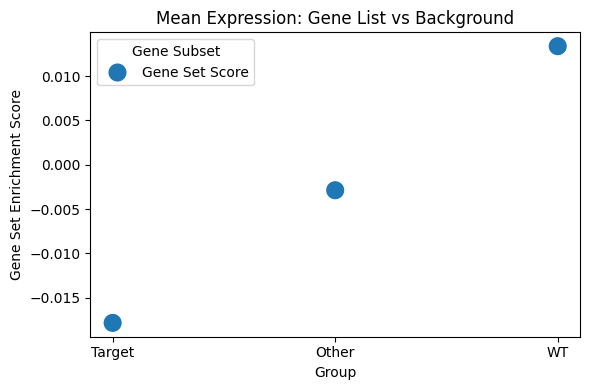

In [25]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Group', y='Mean', hue='Subset', s=200, style='Subset')

# Optional: improve layout
plt.title('Mean Expression: Gene List vs Background')
plt.ylabel('Gene Set Enrichment Score')
plt.legend(title='Gene Subset')
plt.tight_layout()
plt.show()

In [26]:
# Define groups of cells
is_target = adata.obs['mut'] == 'Target'
is_other = adata.obs['mut'] == 'Other'
is_wt = adata.obs['mut'] == 'WT'

# Full gene list and exclusion
all_genes = adata.var_names.tolist()
not_gene_list = list(set(all_genes) - set(gene_list))

# Function to compute average expression of a gene set for a subset of cells
def avg_expr(genes, cell_mask):
    X = adata[cell_mask, genes].X
    if not isinstance(X, np.ndarray):  # if sparse
        X = X.toarray()
    return X.mean()

# Collect mean expression values for in-list vs not-in-list, per group
data = []

for group_name, mask in [('Target', is_target), ('Other', is_other),('WT', is_wt)]:
    mean_in_list = avg_expr(gene_list, mask)
    mean_not_in_list = avg_expr(not_gene_list, mask)
    
    data.append({'Group': group_name, 'Subset': 'In gene list', 'Mean': mean_in_list})
    data.append({'Group': group_name, 'Subset': 'Not in gene list', 'Mean': mean_not_in_list})

df = pd.DataFrame(data)

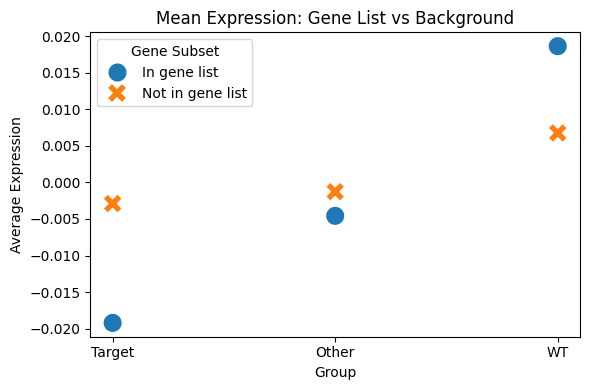

In [27]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Group', y='Mean', hue='Subset', s=200, style='Subset')

# Optional: improve layout
plt.title('Mean Expression: Gene List vs Background')
plt.ylabel('Average Expression')
plt.legend(title='Gene Subset')
plt.tight_layout()
plt.show()

In [47]:
group_1 = adata.obs[adata.obs['mut'] == 'Target']['gene_set_enrichment_score']
group_2 = adata.obs[adata.obs['mut'] == 'Other']['gene_set_enrichment_score']
group_3 = adata.obs[adata.obs['mut'] == 'WT']['gene_set_enrichment_score']

stat, pval = ranksums(group_1.dropna(), group_2.dropna())
print(f'Wilcoxon p-value (GSEA_TO): {pval}')

stat, pval = ranksums(group_1.dropna(), group_3.dropna())
print(f'Wilcoxon p-value (GSEA_TW): {pval}')

stat, pval = ranksums(group_2.dropna(), group_3.dropna())
print(f'Wilcoxon p-value (GSEA_OW): {pval}')

Wilcoxon p-value (GSEA_TO): 0.000764210912760774
Wilcoxon p-value (GSEA_TW): 0.0012361982227246811
Wilcoxon p-value (GSEA_OW): 0.08838062983948347


In [48]:
group_1 = adata.obs[adata.obs['mut'] == 'Target']['gene_signature_avg']
group_2 = adata.obs[adata.obs['mut'] == 'Other']['gene_signature_avg']
group_3 = adata.obs[adata.obs['mut'] == 'WT']['gene_signature_avg']

stat, pval = ranksums(group_1.dropna(), group_2.dropna())
print(f'Wilcoxon p-value (GSEA_TO): {pval}')

stat, pval = ranksums(group_1.dropna(), group_3.dropna())
print(f'Wilcoxon p-value (GSEA_TW): {pval}')

stat, pval = ranksums(group_2.dropna(), group_3.dropna())
print(f'Wilcoxon p-value (GSEA_OW): {pval}')

Wilcoxon p-value (GSEA_TO): 0.0024960608535895103
Wilcoxon p-value (GSEA_TW): 0.0003431427697760998
Wilcoxon p-value (GSEA_OW): 0.01903988633956195


In [28]:
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Target'], reference='Other')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [29]:
# Extract as a DataFrame
import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)
de_genes.head()

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
0,CPLX2,5.903958,NaN,0.000004
1,AKR1B10,4.172807,NaN,0.007552
2,AKR1C3,4.024842,NaN,0.009462
3,GPX2,3.488430,NaN,0.037533
4,ID2,3.485240,3.005309,0.037533


In [30]:
de2 = de_genes.dropna().sort_values(by=['Target_logfoldchanges'],ascending=False)

In [31]:
df = de2.copy()

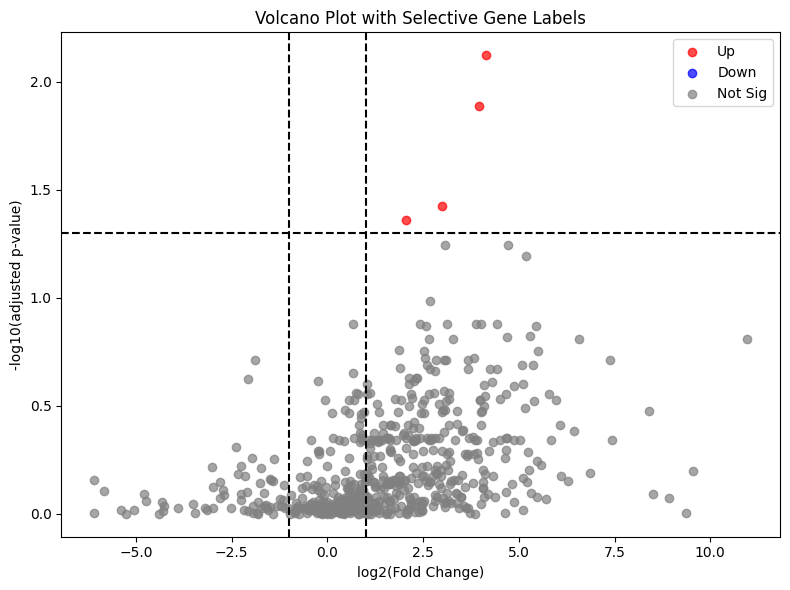

In [32]:
fc_thresh = 1
pval_thresh = 0.05

# Create -log10(padj)
df['neg_log10_padj'] = -np.log10(df['Target_pvals_adj'])

# Label significance
df['significant'] = 'Not Sig'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] > fc_thresh), 'significant'] = 'Up'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] < -fc_thresh), 'significant'] = 'Down'

# Plot
plt.figure(figsize=(8, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}

for sig, color in colors.items():
    subset = df[df['significant'] == sig]
    plt.scatter(subset['Target_logfoldchanges'], subset['neg_log10_padj'], c=color, label=sig, alpha=0.7)

# Filter genes to label: in list AND pass thresholds
label_df = df[
    (df['Target_names'].isin(gene_list)) &
    (df['Target_pvals_adj'] < pval_thresh) &
    (abs(df['Target_logfoldchanges']) > fc_thresh)
]

# Add labels
for _, row in label_df.iterrows():
    plt.text(row['Target_logfoldchanges'], row['neg_log10_padj'], row['Target_names'],
             fontsize=9, ha='right', va='bottom', color='black')

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--')
plt.axvline(fc_thresh, color='black', linestyle='--')
plt.axvline(-fc_thresh, color='black', linestyle='--')

plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot with Selective Gene Labels")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Target'], reference='WT')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [34]:
# Extract as a DataFrame
import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)
de_genes.head()

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
0,C11orf86,18.131954,0.149714,6.805350e-71
1,C1orf61,17.053814,-2.792318,7.498568e-63
2,IQGAP3,16.603256,-1.671545,1.259718e-59
3,SPANXB1,15.144641,NaN,1.045796e-49
4,SERPINB9,14.462390,-0.403822,1.998023e-45


In [35]:
de2 = de_genes.dropna().sort_values(by=['Target_logfoldchanges'],ascending=False)

In [36]:
df = de2.copy()

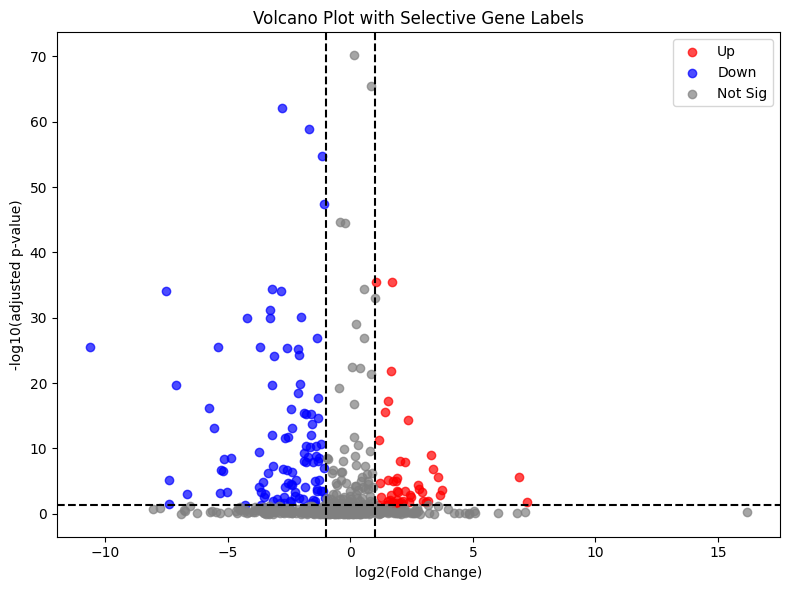

In [37]:
fc_thresh = 1
pval_thresh = 0.05

# Create -log10(padj)
df['neg_log10_padj'] = -np.log10(df['Target_pvals_adj'])

# Label significance
df['significant'] = 'Not Sig'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] > fc_thresh), 'significant'] = 'Up'
df.loc[(df['Target_pvals_adj'] < pval_thresh) & (df['Target_logfoldchanges'] < -fc_thresh), 'significant'] = 'Down'

# Plot
plt.figure(figsize=(8, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}

for sig, color in colors.items():
    subset = df[df['significant'] == sig]
    plt.scatter(subset['Target_logfoldchanges'], subset['neg_log10_padj'], c=color, label=sig, alpha=0.7)

# Filter genes to label: in list AND pass thresholds
label_df = df[
    (df['Target_names'].isin(gene_list)) &
    (df['Target_pvals_adj'] < pval_thresh) &
    (abs(df['Target_logfoldchanges']) > fc_thresh)
]

# Add labels
for _, row in label_df.iterrows():
    plt.text(row['Target_logfoldchanges'], row['neg_log10_padj'], row['Target_names'],
             fontsize=9, ha='right', va='bottom', color='black')

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--')
plt.axvline(fc_thresh, color='black', linestyle='--')
plt.axvline(-fc_thresh, color='black', linestyle='--')

plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot with Selective Gene Labels")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Other'], reference='WT')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [39]:
# Extract as a DataFrame
import pandas as pd
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)
de_genes.head()

,Other_names,Other_scores,Other_logfoldchanges,Other_pvals_adj
0,C11orf86,20.901108,-0.475969,1.996738e-94
1,IQGAP3,18.906075,-4.033691,2.327743e-77
2,C1orf61,18.506952,NaN,3.463253e-74
3,SPANXB1,17.750385,0.574999,2.177736e-68
4,SERPINB9,16.922138,NaN,3.538075e-62


In [40]:
de2 = de_genes.dropna().sort_values(by=['Other_logfoldchanges'],ascending=False)

In [41]:
df = de2.copy()

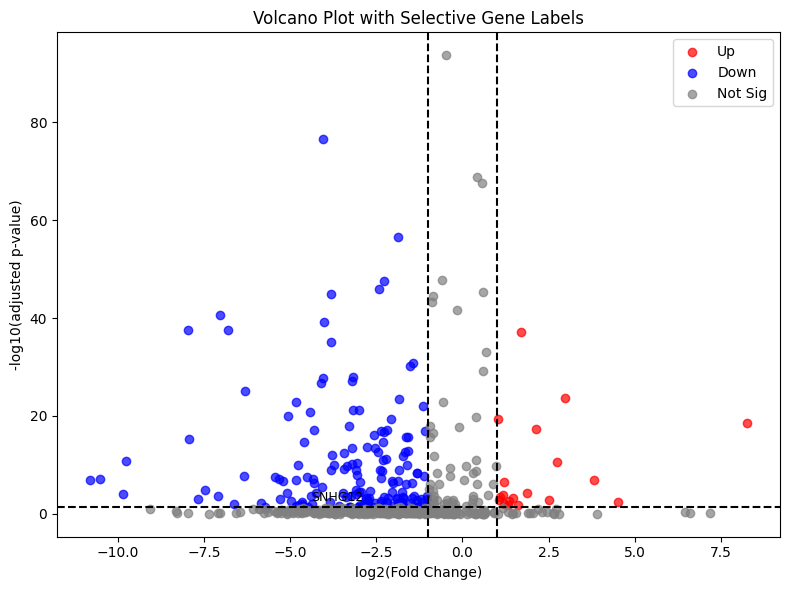

In [42]:
fc_thresh = 1
pval_thresh = 0.05

# Create -log10(padj)
df['neg_log10_padj'] = -np.log10(df['Other_pvals_adj'])

# Label significance
df['significant'] = 'Not Sig'
df.loc[(df['Other_pvals_adj'] < pval_thresh) & (df['Other_logfoldchanges'] > fc_thresh), 'significant'] = 'Up'
df.loc[(df['Other_pvals_adj'] < pval_thresh) & (df['Other_logfoldchanges'] < -fc_thresh), 'significant'] = 'Down'

# Plot
plt.figure(figsize=(8, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}

for sig, color in colors.items():
    subset = df[df['significant'] == sig]
    plt.scatter(subset['Other_logfoldchanges'], subset['neg_log10_padj'], c=color, label=sig, alpha=0.7)

# Filter genes to label: in list AND pass thresholds
label_df = df[
    (df['Other_names'].isin(gene_list)) &
    (df['Other_pvals_adj'] < pval_thresh) &
    (abs(df['Other_logfoldchanges']) > fc_thresh)
]

# Add labels
for _, row in label_df.iterrows():
    plt.text(row['Other_logfoldchanges'], row['neg_log10_padj'], row['Other_names'],
             fontsize=9, ha='right', va='bottom', color='black')

# Threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--')
plt.axvline(fc_thresh, color='black', linestyle='--')
plt.axvline(-fc_thresh, color='black', linestyle='--')

plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot with Selective Gene Labels")
plt.legend()
plt.tight_layout()
plt.show()